[HE] MSE: 1057.23 | PSNR: 17.89 | SSIM: 0.9278
[AHE] MSE: 4118.19 | PSNR: 11.98 | SSIM: 0.4946
[CLAHE] MSE: 778.27 | PSNR: 19.22 | SSIM: 0.8351


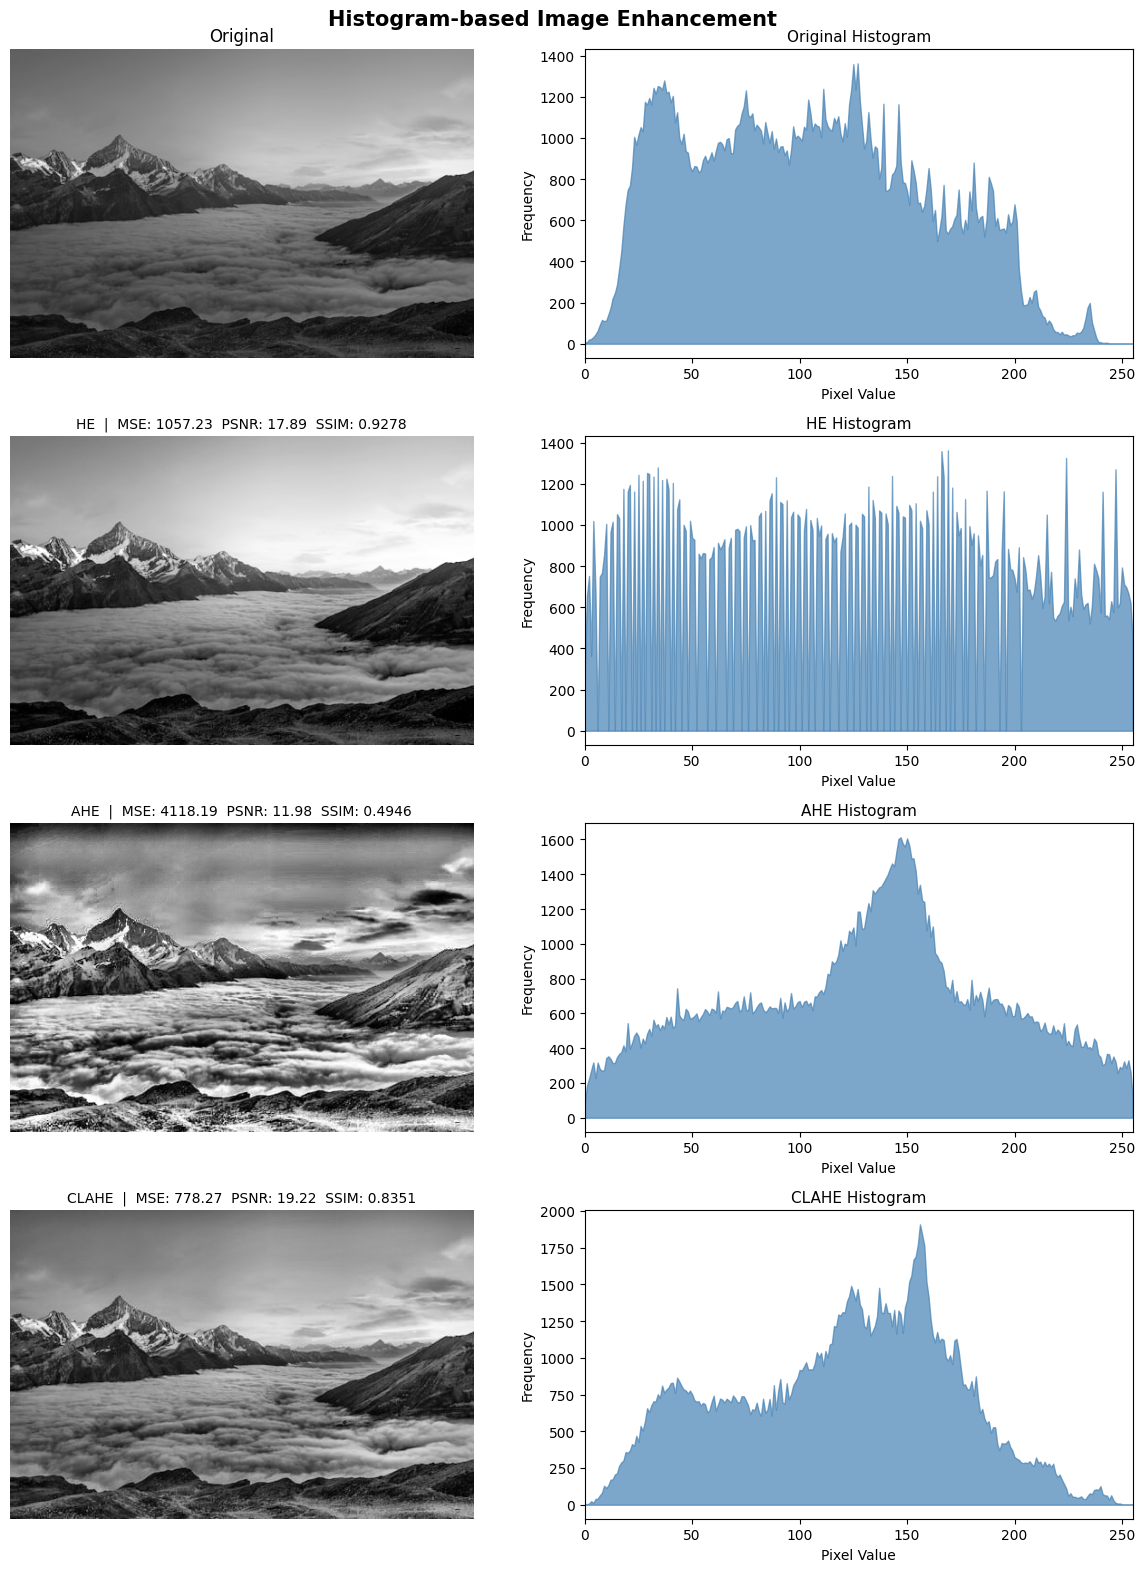

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

# ── 이미지 로드 ──────────────────────────────
urllib.request.urlretrieve(
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=512",
    "she_image.jpg"
)
original = cv2.imread('she_image.jpg', cv2.IMREAD_GRAYSCALE)

# ── 히스토그램 기반 향상 기법 적용 ───────────
def apply_he(img):
    return cv2.equalizeHist(img)

def apply_ahe(img):
    ahe = cv2.createCLAHE(clipLimit=255.0, tileGridSize=(8, 8))
    return ahe.apply(img)

def apply_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)

# ── 평가 지표 계산 ────────────────────────────
def evaluate(ref, target):
    m = mse(ref, target)
    p = psnr(ref, target)
    s = ssim(ref, target, data_range=target.max() - target.min())
    return {'MSE': m, 'PSNR': p, 'SSIM': s}

# ── 처리 및 평가 실행 ─────────────────────────
enhanced = {
    'Original': original,
    'HE'      : apply_he(original),
    'AHE'     : apply_ahe(original),
    'CLAHE'   : apply_clahe(original),
}

scores = {}
for name, img in enhanced.items():
    if name == 'Original':
        continue
    scores[name] = evaluate(original, img)
    print(f"[{name}] MSE: {scores[name]['MSE']:.2f} | "
          f"PSNR: {scores[name]['PSNR']:.2f} | "
          f"SSIM: {scores[name]['SSIM']:.4f}")

# ── 시각화 ────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
fig.suptitle("Histogram-based Image Enhancement", fontsize=15, fontweight='bold')

for row, (name, img) in enumerate(enhanced.items()):
    # 왼쪽: 이미지
    axes[row, 0].imshow(img, cmap='gray')
    if name == 'Original':
        axes[row, 0].set_title(name, fontsize=12)
    else:
        s = scores[name]
        axes[row, 0].set_title(
            f"{name}  |  MSE: {s['MSE']:.2f}  PSNR: {s['PSNR']:.2f}  SSIM: {s['SSIM']:.4f}",
            fontsize=10
        )
    axes[row, 0].axis('off')

    # 오른쪽: 히스토그램
    hist, bins = np.histogram(img.flatten(), bins=256, range=[0, 256])
    axes[row, 1].fill_between(range(256), hist, alpha=0.7, color='steelblue')
    axes[row, 1].set_xlim([0, 255])
    axes[row, 1].set_title(f"{name} Histogram", fontsize=11)
    axes[row, 1].set_xlabel("Pixel Value")
    axes[row, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("histogram_enhancement.png", dpi=150, bbox_inches='tight')
plt.show()